In [6]:
import pathlib
import os
from glob import glob

import numpy as np
import sklearn as sk
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA as pca
from PIL import Image

import morph_analyses as m

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%%bash

unzip ../../../data/FrameGrabber/frame_grabs.zip -d ../../../data/FrameGrabber/

Archive:  ../../../data/FrameGrabber/frame_grabs.zip
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit-0.05_bckgndJit-0.05_towerJit-0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit-0.05_bckgndJit-0.05_towerJit0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit-0.05_bckgndJit0.05_towerJit-0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit-0.05_bckgndJit0.05_towerJit0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit0.05_bckgndJit-0.05_towerJit-0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit0.05_bckgndJit-0.05_towerJit0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit0.05_bckgndJit0.05_towerJit-0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit0.05_bckgndJit0.05_towerJit0.05_pos0.png  
  inflating: ../../../data/FrameGrabber/morph0.25_wallJit-0.05_bckgndJit-0.05_towerJit-0.05_pos100.png  
  inflating: ../../../data/Fra

### Run dimensionality reduction on frame grabs from unity

In [4]:

pics = glob(str(m.params.frame_grabber_dir / "*.png"))

In [8]:
stimDict = {}
for pic in pics:
    # get stimulus values from string
    _,stimstr = os.path.split(pic)
    stimstr,_ = os.path.splitext(stimstr)
    stimparts = stimstr.split("_")
    morph = float(stimparts[0].split("morph")[1])
    walljit = float(stimparts[1].split("wallJit")[1])
    bckgndjit = float(stimparts[2].split("bckgndJit")[1])
    towerjit = float(stimparts[3].split("towerJit")[1])
    pos = float(stimparts[4].split("pos")[1])
    
    stimkey = (morph,walljit,bckgndjit,towerjit)
   
    # if stimulus not yet encountered
    #    make new dictionary key with empty list
    if stimkey not in stimDict.keys():
        stimDict[stimkey]={}
    
    # append file name to dictionary key
    stimDict[stimkey][pos]=pic

In [9]:
# check that each list is the same length
positions,keys = [],[]
for i, (k,v) in enumerate(stimDict.items()):
    keys.append(k)
    positions.append(np.sort(np.array([pos for pos in v.keys()])))

old_row = positions[0]
keystokill =[]
for i, new_row in enumerate(positions):
    if old_row.all() != new_row.all():
        print("row %i is improperly formatted" % i)
        print("key",keys[i])
        keystokill.append(keys[i])
        


row 320 is improperly formatted
key (1.0, 0.06922948, -0.01515506, -0.09076788)


In [10]:
# delete messed p entries
for k in keystokill:
    try:  
        stimDict.pop(k)
        keys.remove(k)
    except KeyError:
        print("key not found",k)

[np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0), np.float64(110.0), np.float64(120.0), np.float64(130.0), np.float64(140.0), np.float64(150.0), np.float64(160.0), np.float64(170.0), np.float64(180.0), np.float64(190.0), np.float64(200.0), np.float64(210.0), np.float64(220.0), np.float64(230.0), np.float64(240.0), np.float64(250.0), np.float64(260.0), np.float64(270.0), np.float64(280.0), np.float64(290.0), np.float64(300.0), np.float64(310.0), np.float64(320.0), np.float64(330.0), np.float64(340.0), np.float64(350.0), np.float64(360.0), np.float64(370.0), np.float64(380.0), np.float64(390.0), np.float64(400.0), np.float64(410.0), np.float64(420.0), np.float64(430.0), np.float64(440.0), np.float64(450.0)]
3
(0.75, -0.1, -0.05, -0.05)
(0.0, -0.1, -0.1, -0.05)
(1.0, -0.05, -0.1, -0.1)
(1.0, -0.1, -0.05, 0.05)
(0.75, 0.0, 0.05, -0.1)
(0.5, 0.05, -0.05, -0.1)


/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/mplitt/repos/PlittGiocomo_CA1Morph_2019/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


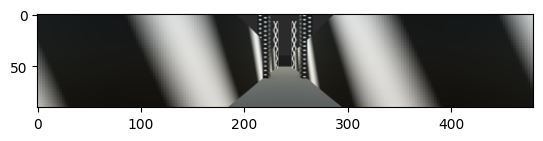

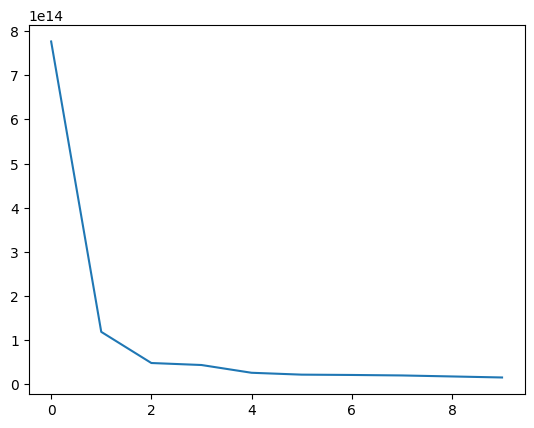

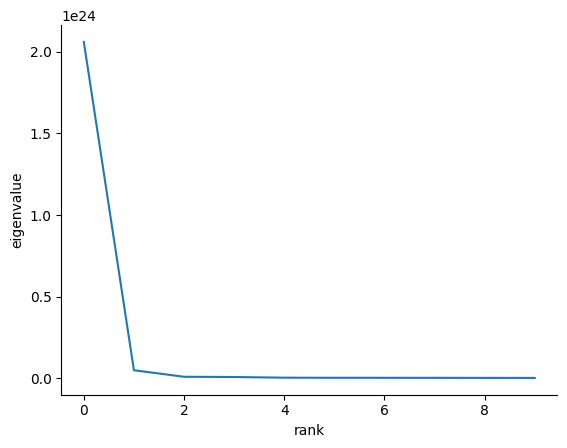

In [12]:
load_prev = False

if load_prev:
    trialcov = np.load("../../../data/FrameGrabber/trialcov.npy")
else:

    # load first file, downsample by 4
    pic = Image.open(pics[10])
    f,ax = plt.subplots()
    pic = np.array(pic.resize((int(pic.size[0]/8),int(pic.size[1]/8))))
    ax.imshow(pic)
    pic_fft = np.fft.rfftn(pic,axes=[0,1])
    pic_as = np.abs(pic_fft[:int((pic.shape[0]-1)/2)+1,:])

    # get size of fft

    # n frames per trial
    pos_keys = [pos for pos in positions[0] if pos >0]
    print(pos_keys)
    pos_keys = pos_keys[::20]
    nframes = len(pos_keys)
    print(nframes)


    # n rows is (size of flattened fft of 1 frame) * (number of frames per trial) x (number of stimulus conditions)
    data = np.zeros((int(nframes*pic_as.size*3),len(keys)))
    for i,key in enumerate(keys):
    # save wall morph, tower morph, background morph
        print(key)
        # for each picture
        for j, pos in enumerate(pos_keys):

            #   load file
            f = stimDict[key][pos]
            pic = Image.open(f)
            pic = np.array(pic.resize((int(pic.size[0]/8),int(pic.size[1]/8)))) # downsample
            pic_fft = np.fft.rfftn(pic,axes=[0,1]) # real fft
            pic_as = np.real(pic_fft[:int((pic.shape[0]-1)/2)+1,:]**2) # take power spectrum
            data[j*pic_as.size:(j+1)*pic_as.size,i]=pic_as.ravel()

    # run svd on memory mapped array 
    s = np.linalg.svd(data[:,:],compute_uv=False)
    f,ax = plt.subplots()
    ax.plot(s[:10])
    
    
    trialcov = np.cov(data.T)
keyarr = np.array(keys)



w,v = np.linalg.eig(trialcov)
f,ax = plt.subplots()
ax.plot(w[:10])
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



princip = np.real(100*v[:,0])
princip_norm = (princip-np.amin(princip))/(np.amax(princip)-np.amin(princip))



[ 0.53305344 -2.38619162 -0.02797924 -0.30357595  1.0703022   0.23353536]
[-3.70700342 -3.13083011 -3.21643483 -3.19406529 -3.20553017 -3.13918249]


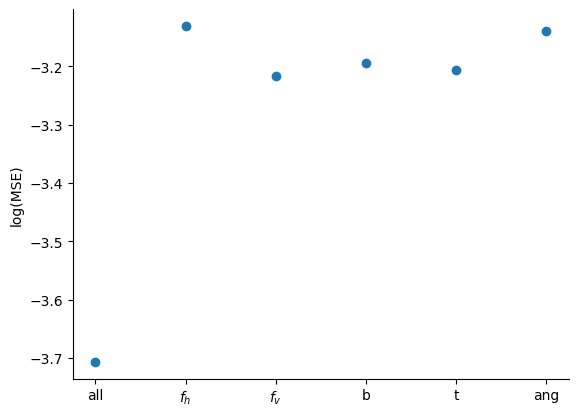

In [13]:
feats = np.zeros((keyarr.shape[0],6))
mask = keyarr[:,0]+keyarr[:,1]>-.1
feats[mask,0]=m.unity_transforms.wallmorphx(keyarr[mask,0]+keyarr[mask,1])
feats[mask,1]=m.unity_transforms.wallmorphy(keyarr[mask,0]+keyarr[mask,1])
feats[mask,2]=keyarr[mask,2]+keyarr[mask,0]
feats[mask,3]=keyarr[mask,3]+keyarr[mask,0]
feats[mask,4]=m.unity_transforms.xfreq(keyarr[mask,0]+keyarr[mask,1])/m.unity_transforms.yfreq(keyarr[mask,0]+keyarr[mask,1])
feats[mask,5]=keyarr[mask,0]

mask = keyarr[:,0]+keyarr[:,1]>-.1

lr = sk.linear_model.LinearRegression()
lr.fit(feats[mask,:],princip_norm[mask])

# f,ax = plt.subplots()
# ax.scatter(lr.predict(feats[mask,:]),princip_norm[mask])
# ax.scatter(lr.predict(feats),lr.predict(feats))
# # ax.scatter()

mse = []
mse.append(((princip_norm-lr.predict(feats))**2).mean())
print(lr.coef_)
for j in range(5):
    lr.fit(feats[:,j:j+1],princip_norm)
    mse.append(((princip_norm - lr.predict(feats[:,j:j+1]))**2).mean())
    
print(np.log(mse))
f,ax = plt.subplots()
ax.scatter(np.arange(6),np.log(mse))
# ax.set_ylim([.08,0])
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['all',"$f_h$","$f_v$", 'b', 't','ang'])
ax.set_ylabel('log(MSE)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



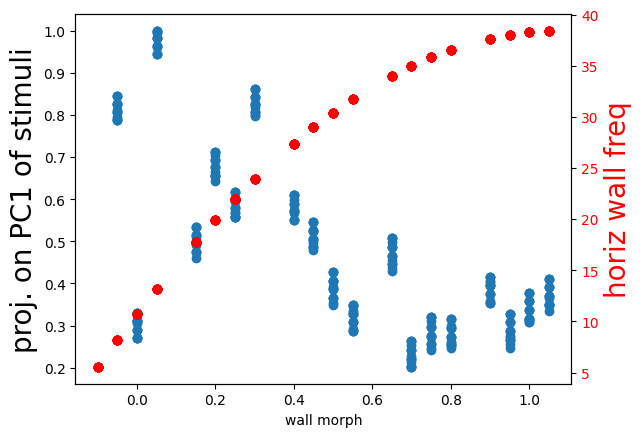

In [14]:
f,ax = plt.subplots()

ax.scatter(keyarr[mask,0]+keyarr[mask,1],princip_norm[mask])
ax.set_ylabel("proj. on PC1 of stimuli",fontsize=20)
ax.set_xlabel("wall morph")
ax2 = ax.twinx()
# ax2.scatter(keys[mask,0]+keys[mask,1],2*wallmorphx(keys[mask,0]+keys[mask,1])-1.*wallmorphy(keys[mask,0]+keys[mask,1]),color='red')
wmx = m.unity_transforms.xfreq(keyarr[:,0]+keyarr[:,1])
wmy =  m.unity_transforms.wallmorphy(keyarr[:,0]+keyarr[:,1])
ax2.scatter(keyarr[:,0]+keyarr[:,1],wmx ,color='red')
ax2.set_ylabel('horiz wall freq',color='red',fontsize=20)
ax2.tick_params(axis='y',labelcolor='red')
f.savefig("D:\\Morph_Results\\figures\\stim_fft_v_wallFreq.pdf",format="pdf")

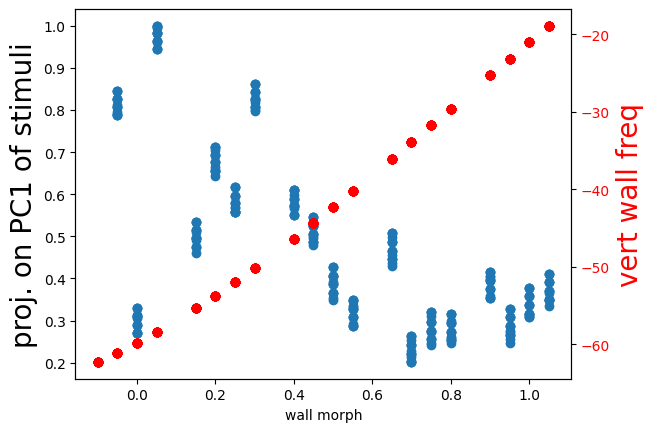

In [15]:
f,ax = plt.subplots()

ax.scatter(keyarr[mask,0]+keyarr[mask,1],princip_norm[mask])
ax.set_ylabel("proj. on PC1 of stimuli",fontsize=20)
ax.set_xlabel("wall morph")
ax2 = ax.twinx()
# ax2.scatter(keys[mask,0]+keys[mask,1],2*wallmorphx(keys[mask,0]+keys[mask,1])-1.*wallmorphy(keys[mask,0]+keys[mask,1]),color='red')
wmx = m.unity_transforms.xfreq(keyarr[:,0]+keyarr[:,1])
wmy =  m.unity_transforms.yfreq(keyarr[:,0]+keyarr[:,1])
ax2.scatter(keyarr[:,0]+keyarr[:,1],1.1-wmy ,color='red')
ax2.set_ylabel('vert wall freq',color='red',fontsize=20)
ax2.tick_params(axis='y',labelcolor='red')


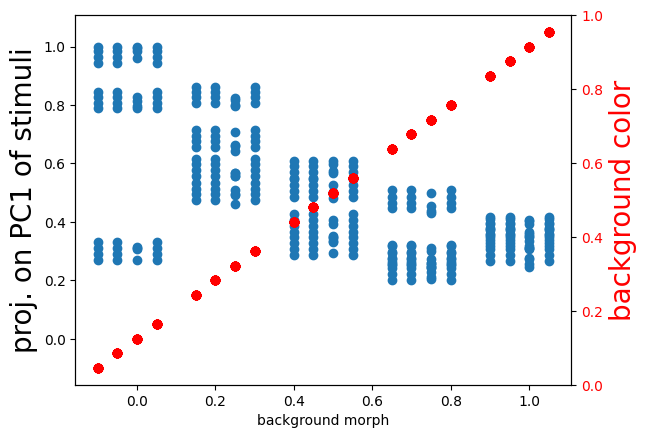

In [16]:
f,ax = plt.subplots()
ax.scatter(keyarr[mask,0]+keyarr[mask,2],princip_norm[mask])
ax.set_ylabel("proj. on PC1 of stimuli",fontsize=20)
ax.set_xlabel("background morph")
ax2 = ax.twinx()
ax.scatter(keyarr[:,0]+keyarr[:,2],keyarr[:,0]+keyarr[:,2],color='red')
ax2.set_ylabel('background color',color='red',fontsize=20)
ax2.tick_params(axis='y',labelcolor='red')
f.savefig("D:\\Morph_Results\\figures\\stim_fft_v_bckgnd.pdf",format="pdf")

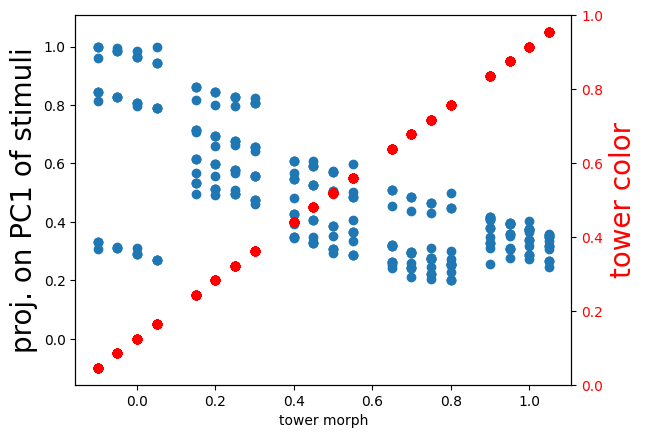

In [17]:
f,ax = plt.subplots()
ax.scatter(keyarr[mask,0]+keyarr[mask,3],princip_norm[mask])
ax.set_ylabel("proj. on PC1 of stimuli",fontsize=20)
ax.set_xlabel("tower morph")
ax2 = ax.twinx()
ax.scatter(keyarr[:,0]+keyarr[:,3],keyarr[:,0]+keyarr[:,3],color='red')
ax2.set_ylabel('tower color',color='red',fontsize=20)
ax2.tick_params(axis='y',labelcolor='red')
